In [1]:
!pip install numpy matplotlib scikit-learn

  Using cached numpy-2.5.0-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.0-cp313-cp313-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached numpy-2.5.0-cp313-cp313-win_amd64.whl (12.4 MB)
Using cached matplotlib-3.11.0-cp313-cp313-win_amd64.whl (9.3 MB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   -- --------------------


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import os

# Create images folder if it doesn't exist
os.makedirs("images", exist_ok=True)

In [3]:

# -------------------------------
# Simple Housing Dataset
# Features: [Size, Bedrooms, Age]
# Target: Price
# -------------------------------

x = np.array([
    [1000, 2, 10],
    [1200, 3, 8],
    [1500, 3, 5],
    [1800, 4, 2]
]).astype(float)

y = np.array([200000, 250000, 300000, 350000]).astype(float)


In [4]:
# -------------------------------
# Feature Scaling (Standardization)
# -------------------------------

x_mean = np.mean(x, axis=0)
x_std = np.std(x, axis=0)

x_scaled = (x - x_mean) / x_std

In [5]:
# -------------------------------
# Initialize parameters
# -------------------------------

w = np.zeros(x.shape[1])  # weights
b = 0.0                    # bias
alpha = 0.001              # learning rate

In [6]:
# -------------------------------
# Compute Cost Function
# -------------------------------

def compute_cost(x, y, w, b):
    m = x.shape[0]
    total_cost = 0

    for i in range(m):
        prediction = np.dot(x[i], w) + b
        error = prediction - y[i]
        total_cost += error ** 2

    return total_cost / (2 * m)

In [7]:
# -------------------------------
# Compute Gradients
# -------------------------------

def compute_gradient(x, y, w, b):
    m = x.shape[0]
    dj_dw = np.zeros_like(w)
    dj_db = 0

    for i in range(m):
        error = np.dot(x[i], w) + b - y[i]
        dj_dw += error * x[i]
        dj_db += error

    dj_dw /= m
    dj_db /= m

    return dj_dw, dj_db

In [8]:
# -------------------------------
# Training using Gradient Descent
# -------------------------------

J_history = []

epochs = 3000

for epoch in range(epochs):

    dj_dw, dj_db = compute_gradient(x_scaled, y, w, b)

    w -= alpha * dj_dw
    b -= alpha * dj_db

    cost = compute_cost(x_scaled, y, w, b)
    J_history.append(cost)

    if epoch % 300 == 0:
        print(f"Epoch {epoch}: Cost {cost:.2f}")

Epoch 0: Cost 39290414448.34
Epoch 300: Cost 20986421058.55
Epoch 600: Cost 11420142782.08
Epoch 900: Cost 6254328444.20
Epoch 1200: Cost 3434398246.93
Epoch 1500: Cost 1889637723.50
Epoch 1800: Cost 1042432056.01
Epoch 2100: Cost 577583733.32
Epoch 2400: Cost 322457576.05
Epoch 2700: Cost 182389232.71


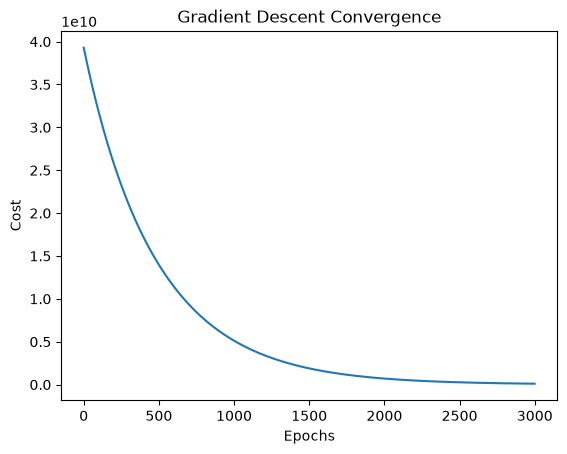

In [9]:
# -------------------------------
# Plot Cost Function
# -------------------------------

plt.figure()
plt.plot(J_history)
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.title("Gradient Descent Convergence")

plt.savefig("images/cost_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
# -------------------------------
# Prediction Function
# -------------------------------

def predict(x_new):
    x_new_scaled = (x_new - x_mean) / x_std
    return np.dot(x_new_scaled, w) + b

In [11]:
x_new = np.array([1600, 3, 6])
print("Prediction (Scratch Model):", predict(x_new))

Prediction (Scratch Model): 277931.0599852967


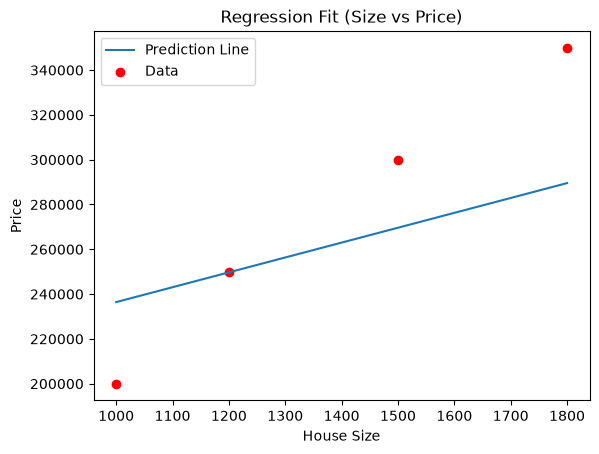

In [13]:
# -------------------------------
# Regression visualization
# -------------------------------

x1 = np.linspace(min(x[:, 0]), max(x[:, 0]), 100)
x2 = np.mean(x[:, 1])
x3 = np.mean(x[:, 2])

X_plot = np.array([[i, x2, x3] for i in x1])
X_plot_scaled = (X_plot - x_mean) / x_std

y_plot = np.dot(X_plot_scaled, w) + b

plt.figure()
plt.plot(x1, y_plot, label="Prediction Line")
plt.scatter(x[:, 0], y, color='red', label="Data")

plt.xlabel("House Size")
plt.ylabel("Price")
plt.title("Regression Fit (Size vs Price)")
plt.legend()

plt.savefig("images/regression_fit.png", dpi=300, bbox_inches="tight")
plt.show()

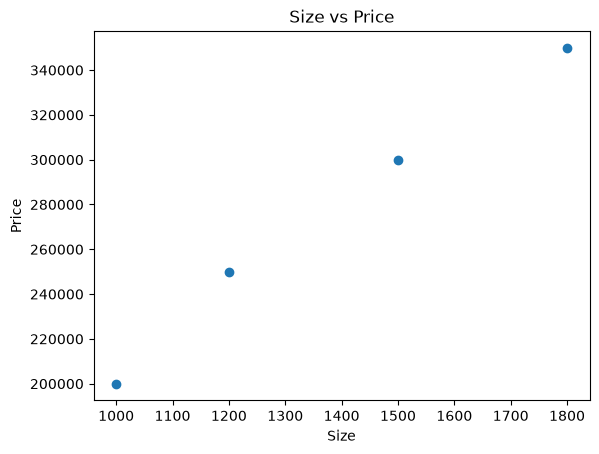

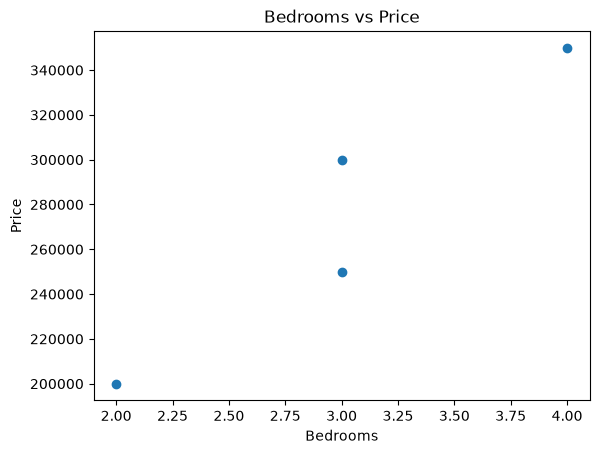

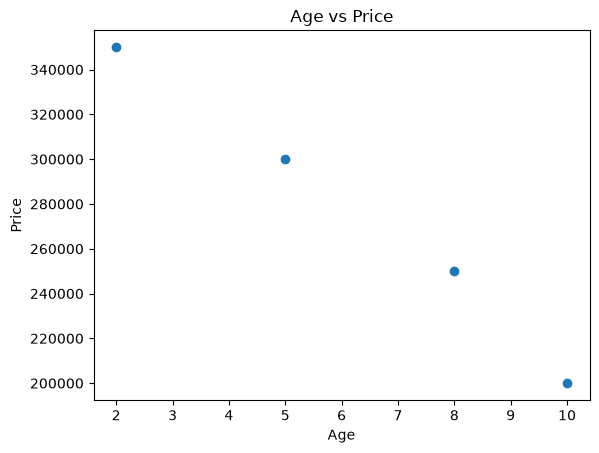

In [14]:
# -------------------------------
# Feature vs Price plots
# -------------------------------

# Size vs Price
plt.figure()
plt.scatter(x[:, 0], y)
plt.xlabel("Size")
plt.ylabel("Price")
plt.title("Size vs Price")

plt.savefig("images/size_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()

# Bedrooms vs Price
plt.figure()
plt.scatter(x[:, 1], y)
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.title("Bedrooms vs Price")

plt.savefig("images/bedrooms_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()

# Age vs Price
plt.figure()
plt.scatter(x[:, 2], y)
plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Age vs Price")

plt.savefig("images/age_vs_price.png", dpi=300, bbox_inches="tight")
plt.show()

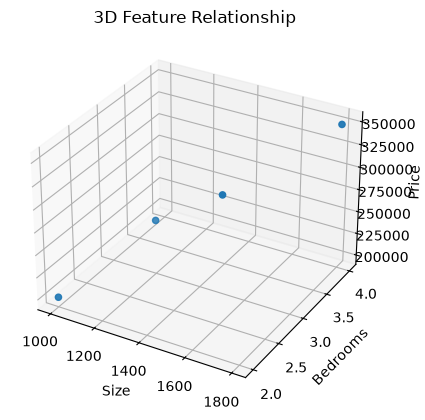

In [15]:
# -------------------------------
# 3D Scatter Plot
# -------------------------------

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x[:, 0], x[:, 1], y)

ax.set_xlabel("Size")
ax.set_ylabel("Bedrooms")
ax.set_zlabel("Price")

plt.title("3D Feature Relationship")

plt.savefig("images/3d_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
# -------------------------------
# Sklearn Linear Regression
# -------------------------------

model = LinearRegression()
model.fit(x, y)

x_new = np.array([[1600, 3, 6]])
print("Prediction (Sklearn):", model.predict(x_new))

Prediction (Sklearn): [310523.15821049]
